# Task 3 - CNNs, ResNets, Transfer Learning and Grad-CAM

# Topics

In this exercise sheet, you will:
- Work with a dataset consisting of images of electronic waste.
- Implement a CNN for classification
- Compare MLP and CNN
- Vary architecture to improve model performance
- Implement a ResNet
- Apply transfer learning using ResNet50
- Apply Grad-CAM class activation visualization

*We are looking forward to seeing your solutions! Have fun!*

## Tutorials

Some python libraries are required to accomplish the tasks assigned in this homework. If you feel like you need to follow a tutorial before, feel free to do so:
*   [Scikit-learn Tutorials](https://www.tensorflow.org/tutorials)
*   [TensorFlow Tutorials](https://scikit-learn.org/stable/tutorial/index.html)
*   [Matplotlib Tutorials](https://matplotlib.org/stable/tutorials/index.html)

## Imports

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, optimizers, losses, callbacks
import seaborn as sns
import matplotlib.pyplot as plt

gpus = tf.config.list_physical_devices('GPU')
tf.config.set_visible_devices(gpus, 'GPU')

# Subtask 2.1

## Loading e-waste dataset



The data is available here: [https://tucloud.tu-clausthal.de/index.php/s/HMle0Ievm3ITBu0](https://tucloud.tu-clausthal.de/index.php/s/HMle0Ievm3ITBu0)

Password is: EK_data


In this task, we are looking for an automated classification of electronic waste to seven classes, e.g. those containing wood, glass etc. To this end, a dataset containing images of different types of electronic waste is prepared. The data is provided as a `zip` file. Please, extract it in a directory.

Use `tf.keras.utils.image_dataset_from_directory` to load the dataset from the directory. We have in total 9,906 samples and 7 classes.

#### TODO

- Consider 80% of the samples for training and 20% for validation.
- Use a batch size of 32
- Resize the image to image height and width of 224 $\times$ 224.

In [ ]:
from google.colab import files
import zipfile
import os

In [ ]:
uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [ ]:
with zipfile.ZipFile("/content/Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("Dataset")

In [19]:
# TODO load dataset from directory
data_dir = "Dataset"
batch_size = 32
img_height = 224
img_width = 224
num_classes = 7

# tarining data (%80)
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"  # one-hot encoding
)

# validation data (%20)
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

Found 9906 files belonging to 7 classes.
Using 7925 files for training.
Found 9906 files belonging to 7 classes.
Using 1981 files for validation.


#### TODO
- Print the name of classes.

In [20]:
# name of classes
class_names = train_ds.class_names
print("name of classes:", class_names)

name of classes: ['EK glashaltig', 'EK hochwertig', 'EK holzhaltig', 'Gewerbeabfall', 'Kunststoff', 'Mischkunststoff', 'metallreich']


Let us visualize some samples of the training dataset and their corresponding labels.

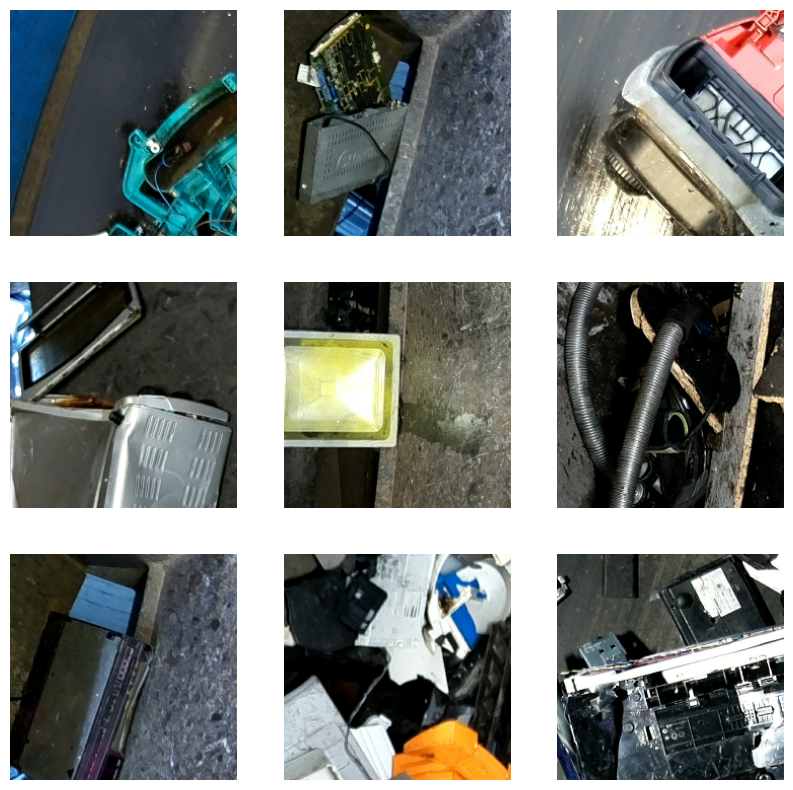

In [21]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    # plt.title(class_names[labels[i]])
    plt.axis("off")


# Subtask 2.2

## Convolution and Pooling operations

![model]( 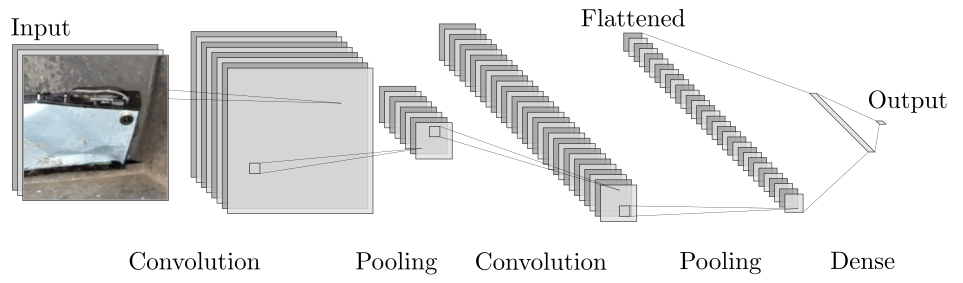)



Let us start by applying convolution and pooling operations on a batch of samples.
#### TODO
 - Take one batch of samples from the training data set.
 - Create a convolution layer containing 8 filters with the size of 3 $\times$ 3 and stride of 1.
 - Apply convolution on the images.
 - Print the input shape.
 - Print the output shape.

In [22]:
image, label =  zip(*train_ds.take(1))
x = image[0]

images, labels = next(iter(train_ds)) # batch unpacking

print("Input shape = ",images.shape)

conv_layer = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3,3),
    strides=1,
    padding="valid",
    activation=None
)

output = conv_layer(images)

print("output shape after Conv2D: ", output.shape)

Input shape =  (32, 224, 224, 3)
output shape after Conv2D:  (32, 222, 222, 8)


#### TODO
- Print shape of the trainable parameters of the layer. You can use `get_weights()` method.

In [ ]:
weights = conv_layer.get_weights()

print("Kernel shape: ", weights[0].shape)

print("Bias shape: ", weights[1].shape)

Kernel shape:  (3, 3, 3, 8)
Bias shape:  (8,)


#### TODO
 - Perform zero padding to get the same shape after convolution.

In [ ]:
conv_layer_same = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3,3),
    padding= "same",
    strides=1,
    activation=None
)

output_same = conv_layer_same(images)

print("Input shape: ", images.shape)

print("output shape with padding=same: ", output_same.shape)

Input shape:  (32, 224, 224, 3)
output shape with padding=same:  (32, 224, 224, 8)


#### TODO
 - Perform convolution as before but with the stride of 2.
 - Print the input and output shapes.

In [ ]:
conv_layer_stride2 = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3,3),
    padding= "same",
    strides=2,
    activation=None
)

output_stride2 = conv_layer_stride2(images)

print("Input shape: ", images.shape)

print("output shape with padding=same: ", output_stride2.shape)

Input shape:  (32, 224, 224, 3)
output shape with padding=same:  (32, 112, 112, 8)


#### TODO
- Create a max pooling layer with the pool size of `(2, 2)`.
- Apply the max pooling operation on a batch of samples.
- Print the input and output shapes.
- Print shape of the trainable parameters.

In [ ]:
images, labels = next(iter(train_ds)) # batch unpacking

pool_layer = tf.keras.layers.MaxPool2D(pool_size=(2,2))

pooled_output = pool_layer(images)

print("Input shape: ", images.shape)
print("Output shape after Pooling: ", pooled_output.shape)

trainable_params = pool_layer.trainable_variables
print("shape of the trainable parameters: ", len(trainable_params))

Input shape:  (32, 224, 224, 3)
Output shape after Pooling:  (32, 112, 112, 3)
shape of the trainable parameters:  0


*Since MaxPooling simply selects the maximum value from certain regions, there is nothing to learn — so it has no parameters.*

#### TODO
- Create a global average pooling layer.
- Apply the global average pooling operation on a batch of samples.
- Print the input and output shapes.


In [ ]:
images, layers = next(iter(train_ds))

gap_layer = tf.keras.layers.GlobalAveragePooling2D()

gap_output = gap_layer(images)

print("Input shape: ", images.shape)
print("Output shape after GlobalAveragePooling2D", gap_output.shape)

Input shape:  (32, 224, 224, 3)
Output shape after GlobalAveragePooling2D (32, 3)


# Subtask 2.3

## Convolutional neural networks (CNNs)

#### TODO
- Implement a simple CNN model for classification. You need the following layers:
    - Input
    - Rescaling by a factor of 1/225.
    - Convolution with 8 filters of the size of 3 $\times$ 3 and stride 1.
    - Max pooling with a pool size of `(2, 2)`.
    - Flatten
    - Dense with number of neurons equal to number of classes and `softmax` activation function.
- Print `model.summary()`.
- Train the network using `Adam` optimizer with the learning rate of 0.001 for 20 epochs.
- Use `SparseCategoricalCrossentropy` as the loss function.
- Compute and report the accuracy during training. In `model.compile()` you can set `metrics = ['accuracy']`.
- Use model checkpoints to save the best model.
- Plot the learning curves using the `plot_learning_curves` function provided below.
    


In [ ]:
def plot_learning_curves(hist):
    epochs = np.arange(0, len(hist.history['loss'])) + 1
    sns.set(style='ticks')
    fig, ax = plt.subplots(1, 2, figsize = (10, 4), sharex=True)
    ax[0].plot(epochs, hist.history['loss'], label = 'Training loss', marker = 'o', ls = '--')
    ax[0].plot(epochs, hist.history['val_loss'], label = 'Validation loss', marker = 'o', ls = '--')

    ax[1].plot(epochs, hist.history['accuracy'], label = 'Training accuracy', marker = 'o', ls = '--')
    ax[1].plot(epochs, hist.history['val_accuracy'], label = 'Validation accuracy', marker = 'o', ls = '--')

    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Loss vs. Epoch')
    ax[0].legend()

    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Accuracy vs. Epoch')
    ax[1].legend()
    sns.despine(trim=True, offset=5)

In [ ]:
from tensorflow.keras import layers, Model, optimizers

inputs = layers.Input(shape=(img_height, img_width, 3))

# Normalization
x = layers.Rescaling(1./255)(inputs)

# Conv + MaxPooling
x = layers.Conv2D(filters=8, kernel_size=(3, 3), strides=1, padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# Flatten
x = layers.Flatten()(x)

# output
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = Model(inputs=inputs, outputs=outputs)

model.summary()

# Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='CategoricalCrossentropy',
              metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │       702,471 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,695 (2.68 MB)

 Trainable params: 702,695 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import  callbacks, losses

In [ ]:
checkpoint_cb = callbacks.ModelCheckpoint(
    "best_cnn_model.h5", save_best_only=True, monitor="val_accuracy", mode="max"
)

# train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb]
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4812 - loss: 1.6061

248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.4817 - loss: 1.6046 - val_accuracy: 0.6764 - val_loss: 0.9588
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8318 - loss: 0.6002

248/248 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.8319 - loss: 0.5999 - val_accuracy: 0.6936 - val_loss: 0.9087
Epoch 3/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9376 - loss: 0.2799

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9377 - loss: 0.2795 - val_accuracy: 0.7183 - val_loss: 0.8702
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9807 - loss: 0.1178

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.9807 - loss: 0.1177 - val_accuracy: 0.7269 - val_loss: 0.9072
Epoch 5/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9960 - loss: 0.0551

248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.9960 - loss: 0.0551 - val_accuracy: 0.7299 - val_loss: 0.9260
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9992 - loss: 0.0250 - val_accuracy: 0.7264 - val_loss: 0.9492
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9997 - loss: 0.0140 - val_accuracy: 0.7274 - val_loss: 1.0193
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.7143 - val_loss: 1.0375
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.7239 - val_loss: 1.0596
Epoch 10/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.7224 - val_loss: 1.0927
Epoch 11/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.7239 - val_loss: 1.1231
Epoch 12/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accu

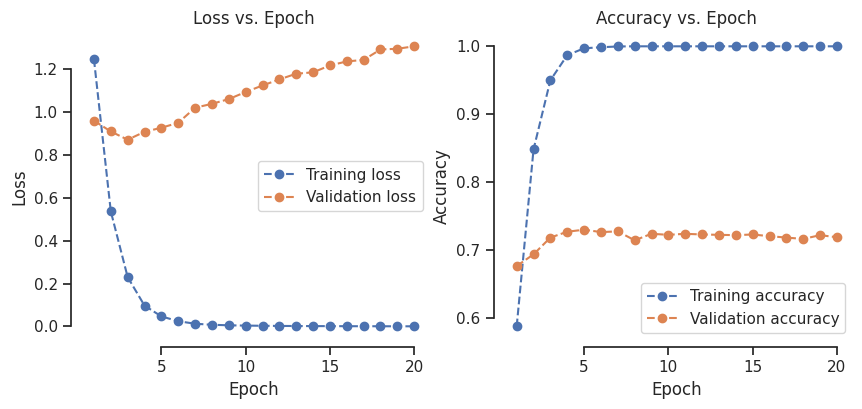

In [ ]:
# TODO plot learning curves
plot_learning_curves(history)

# Subtask 2.4

## Compare CNN with MLP

#### TODO
- Train an MLP model and compare the results with the CNN model you trained regarding the performance of the model, time of training, and the number of parameters.

In [ ]:
from tensorflow.keras import Model

# MLP model
inputs_mlp = layers.Input(shape=(img_height, img_width, 3))
x_mlp = layers.Rescaling(1./255)(inputs_mlp)  # Normalization
x_mlp = layers.Flatten()(x_mlp)               # convert to vectors

# Dense layers
x_mlp = layers.Dense(128, activation='relu')(x_mlp)
x_mlp = layers.Dense(64, activation='relu')(x_mlp)

# output layer
outputs_mlp = layers.Dense(num_classes, activation='softmax')(x_mlp)

# Model
mlp_model = Model(inputs=inputs_mlp, outputs=outputs_mlp)

mlp_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,276,423 (73.53 MB)

 Trainable params: 19,276,423 (73.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile
mlp_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='CategoricalCrossentropy',
              metrics=['accuracy'])
# MLP
mlp_checkpoint_cb = callbacks.ModelCheckpoint(
    "best_mlp_model.h5", save_best_only=True, monitor="val_accuracy", mode="max"
)
# Train
mlp_history = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[mlp_checkpoint_cb]
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2001 - loss: 13.1976

248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.2002 - loss: 13.1704 - val_accuracy: 0.2408 - val_loss: 2.7983
Epoch 2/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3006 - loss: 2.3804

248/248 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.3006 - loss: 2.3788 - val_accuracy: 0.2877 - val_loss: 1.9649
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.3412 - loss: 1.8521 - val_accuracy: 0.2731 - val_loss: 2.2207
Epoch 4/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3882 - loss: 1.6791

248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.3883 - loss: 1.6790 - val_accuracy: 0.3554 - val_loss: 1.7754
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.4190 - loss: 1.6128 - val_accuracy: 0.3478 - val_loss: 1.7296
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.4445 - loss: 1.5002 - val_accuracy: 0.2923 - val_loss: 1.9604
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4285 - loss: 1.5643

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.4286 - loss: 1.5641 - val_accuracy: 0.3700 - val_loss: 1.6949
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.4442 - loss: 1.4891 - val_accuracy: 0.3629 - val_loss: 1.7940
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.4458 - loss: 1.4914 - val_accuracy: 0.3660 - val_loss: 1.7096
Epoch 10/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.4737 - loss: 1.4205 - val_accuracy: 0.3140 - val_loss: 1.8383
Epoch 11/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.4613 - loss: 1.4340 - val_accuracy: 0.3523 - val_loss: 1.8254
Epoch 12/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.4910 - loss: 1.3899 - val_accuracy: 0.2569 - val_loss: 2.6221
Epoch 13/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4678 - loss: 1.4582

248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.4678 - loss: 1.4580 - val_accuracy: 0.3958 - val_loss: 1.6253
Epoch 14/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.4773 - loss: 1.3964 - val_accuracy: 0.3569 - val_loss: 1.7115
Epoch 15/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.4624 - loss: 1.3993 - val_accuracy: 0.3685 - val_loss: 1.6831
Epoch 16/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.3856 - loss: 1.5720 - val_accuracy: 0.3448 - val_loss: 1.6902
Epoch 17/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.4077 - loss: 1.5211 - val_accuracy: 0.3423 - val_loss: 1.6896
Epoch 18/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.3833 - loss: 1.5808 - val_accuracy: 0.3034 - val_loss: 1.8281
Epoch 19/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.4194 - loss: 1.5225 - val_accuracy: 0.3594 - val_loss: 1.6947
Epoch 20/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.4246 - loss: 1.4865 - val_

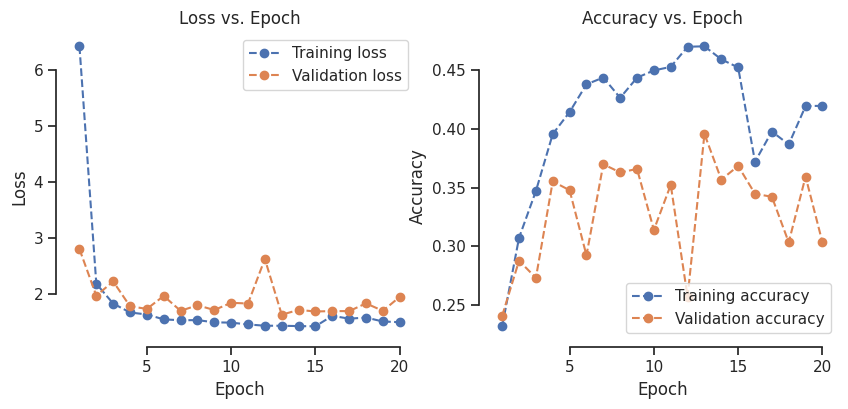

In [ ]:
plot_learning_curves(mlp_history)

In [ ]:
import pandas as pd
import time

# validations
cnn_train_acc = history.history['accuracy'][-1]
cnn_val_acc = history.history['val_accuracy'][-1]
mlp_train_acc = mlp_history.history['accuracy'][-1]
mlp_val_acc = mlp_history.history['val_accuracy'][-1]

# Parameter
cnn_params = model.count_params()
mlp_params = mlp_model.count_params()

# comparison
comparison_df = pd.DataFrame({
    'Model': ['CNN', 'MLP'],
    'Train Accuracy': [f"{cnn_train_acc:.4f}", f"{mlp_train_acc:.4f}"],
    'Validation Accuracy': [f"{cnn_val_acc:.4f}", f"{mlp_val_acc:.4f}"],
    'Num Parameters': [cnn_params, mlp_params],
    'Training Time (approx.)': ['(check logs)', '(check logs)']
})

# show
print("\nModel Comparation:")
display(comparison_df)



Model Comparation:


,Model,Train Accuracy,Validation Accuracy,Num Parameters,Training Time (approx.)
0,CNN,1.0000,0.7188,702695,(check logs)
1,MLP,0.4198,0.3034,19276423,(check logs)


# Subtask 2.5

## Model architecture

We did only one step of down-sampling using the max-pooling layer. From `model.summary()` we can see that a Dense layer that maps a vector with the size of 111 $\times$ 111 $\times$ 8 to the output size of 7 is needed. Having a layer with such large number of parameters is prone to over-fitting. Let us perform more steps of down-sampling to avoid this.

#### TODO
 - Keep everything the same as the previous TODO, but perform four steps of convolution and max-pooling rather than just one.
 - In each step of down-sampling double the number of filters.


In [ ]:

inputs = layers.Input(shape=(img_height, img_width, 3))

x = layers.Rescaling(1./255)(inputs)

# 1. Conv + MaxPooling
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# 2. Conv + MaxPooling
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# 3. Conv + MaxPooling
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# 4. Conv + MaxPooling
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# Flatten + Dense output
x = layers.Flatten()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = models.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │        87,815 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,343 (438.84 KB)

 Trainable params: 112,343 (438.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TODO compile and train the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='CategoricalCrossentropy',
    metrics=['accuracy']
)

# save the model
checkpoint_cb = callbacks.ModelCheckpoint("best_model_4layer.h5", save_best_only=True)

# train
history_deep = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb]
)



Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3507 - loss: 1.6407

248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.3513 - loss: 1.6396 - val_accuracy: 0.6966 - val_loss: 0.8911
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7279 - loss: 0.8382

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.7280 - loss: 0.8377 - val_accuracy: 0.7865 - val_loss: 0.6397
Epoch 3/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8350 - loss: 0.5008

248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.8351 - loss: 0.5003 - val_accuracy: 0.8496 - val_loss: 0.4407
Epoch 4/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8961 - loss: 0.3221

248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.8961 - loss: 0.3220 - val_accuracy: 0.8662 - val_loss: 0.4100
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9302 - loss: 0.2356

248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9302 - loss: 0.2355 - val_accuracy: 0.8834 - val_loss: 0.3596
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.9632 - loss: 0.1286 - val_accuracy: 0.8854 - val_loss: 0.3871
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9758 - loss: 0.0867 - val_accuracy: 0.8864 - val_loss: 0.4125
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.9792 - loss: 0.0709 - val_accuracy: 0.8642 - val_loss: 0.5542
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.9793 - loss: 0.0687 - val_accuracy: 0.8819 - val_loss: 0.4015
Epoch 10/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9880 - loss: 0.0441 - val_accuracy: 0.8869 - val_loss: 0.4515
Epoch 11/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9995 - loss: 0.0086 - val_accuracy: 0.8910 - val_loss: 0.4985
Epoch 12/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9996 - loss: 0.0044 - val_accu

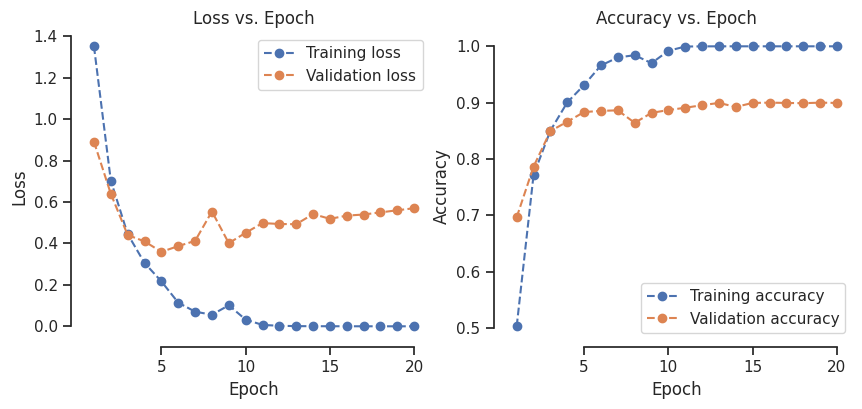

In [ ]:
# TODO plot learning curves

plot_learning_curves(history_deep)

You can also perform global average pooling and down-sample the input image to a vector. Let us implement a `GlobalAveragePooling2D` layer rather than the `Flatten` layer.

#### TODO
- Keep every setting as the previous TODO, and replace the `Flatten` layer with `GlobalAveragePooling2D`.
- Train the model for 20 epochs.

In [ ]:
inputs = layers.Input(shape=(img_height, img_width, 3))

x = layers.Rescaling(1./255)(inputs)

# 1. Conv + MaxPooling
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 2. Conv + MaxPooling
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 3. Conv + MaxPooling
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 4. Conv + MaxPooling
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Global Average Pooling (intead of Flatten)
x = layers.GlobalAveragePooling2D()(x)

# output
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = models.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,983 (97.59 KB)

 Trainable params: 24,983 (97.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TODO compile and train the model

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='CategoricalCrossentropy',
    metrics=['accuracy']
)

# Checkpoint
checkpoint_cb = callbacks.ModelCheckpoint("best_model_gap.h5", save_best_only=True)

# train
history_gap = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb]
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2451 - loss: 1.8336

248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.2454 - loss: 1.8332 - val_accuracy: 0.4190 - val_loss: 1.5428
Epoch 2/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4847 - loss: 1.4609

248/248 ━━━━━━━━━━━━━━━━━━━━ 39s 79ms/step - accuracy: 0.4850 - loss: 1.4601 - val_accuracy: 0.6254 - val_loss: 1.1305
Epoch 3/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6212 - loss: 1.1145

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.6213 - loss: 1.1141 - val_accuracy: 0.6355 - val_loss: 1.0044
Epoch 4/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6745 - loss: 0.9402

248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.6746 - loss: 0.9399 - val_accuracy: 0.7183 - val_loss: 0.8366
Epoch 5/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7150 - loss: 0.8375

...

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.8414 - loss: 0.4804 - val_accuracy: 0.8405 - val_loss: 0.4771
Epoch 14/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.8505 - loss: 0.4514 - val_accuracy: 0.8198 - val_loss: 0.5342
Epoch 15/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8570 - loss: 0.4370

248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.8569 - loss: 0.4371 - val_accuracy: 0.8713 - val_loss: 0.4253
Epoch 16/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8643 - loss: 0.4108

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.8643 - loss: 0.4108 - val_accuracy: 0.8718 - val_loss: 0.4046
Epoch 17/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8672 - loss: 0.3978

248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.8672 - loss: 0.3979 - val_accuracy: 0.8718 - val_loss: 0.4018
Epoch 18/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8734 - loss: 0.3728

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.8734 - loss: 0.3729 - val_accuracy: 0.8910 - val_loss: 0.3507
Epoch 19/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.8812 - loss: 0.3592 - val_accuracy: 0.8521 - val_loss: 0.4580
Epoch 20/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8811 - loss: 0.3529 - val_accuracy: 0.8718 - val_loss: 0.3961


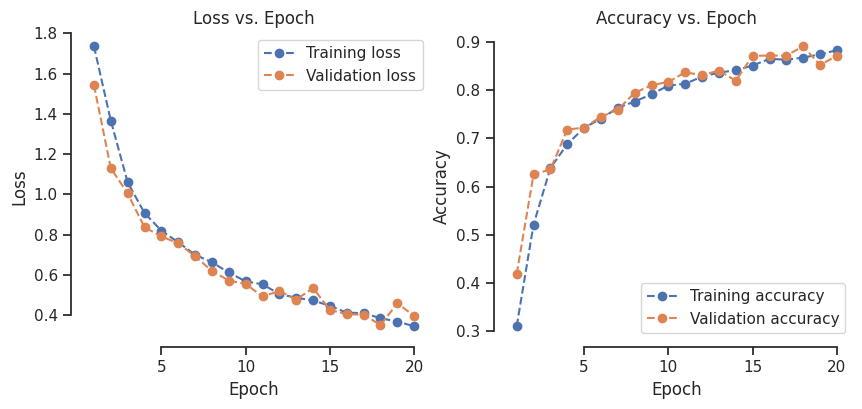

In [ ]:
# TODO plot learning curves

plot_learning_curves(history_gap)

# Subtask 2.6
## Challenge

#### TODO
- Modify the architecture to obtain higher accuracy.
- You may use regularization and `BatchNormalization`.

In [ ]:
inputs = layers.Input(shape=(img_height, img_width, 3))
x = layers.Rescaling(1./255)(inputs)

# 1. Block: Conv + BN + ReLU + MaxPool
x = layers.Conv2D(16, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 2. Block
x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 3. Block
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 4. Block
x = layers.Conv2D(128, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)


x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)

# Output
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,303 (387.90 KB)

 Trainable params: 98,823 (386.03 KB)

 Non-trainable params: 480 (1.88 KB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='CategoricalCrossentropy',
    metrics=['accuracy']
)

checkpoint_cb = callbacks.ModelCheckpoint("best_model_bn_dropout.h5", save_best_only=True)

history_bn_dropout = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb]
)

# Subtask 2.7
## ResNet architecture


"*Deeper neural networks are more difficult to train.  We present a residual learning framework to ease the training of networks that are substantially deeper than those used previously.*" [ https://arxiv.org/pdf/1512.03385.pdf]

That was the intention of He et al. to develop residual networks.

A ResNet is built of blocks which are called the *Residual Blocks*.
A residual block uses *skip connections* - shortCuts — to jump over some layers to skip some activations.
The Resnet skips connections via addition.

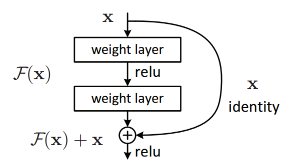

#### **Questions**
- Which problems do using skip connections solve?
- Why is a residual network called residual?
- When is the advantage of ResNets over 'normal' CNNs most visible?

<span style='color:red'>**Your answer:**</span>

1) Skip connections (also known as shortcut connections) address two major problems in deep neural networks:
*   Vanishing gradient problem: In very deep networks,
gradients can become extremely small as they are backpropagated through many layers. Skip connections provide alternate paths for the gradients, making training more stable and enabling deeper networks to learn effectively.
*   Degradation problem: As networks get deeper, their performance can actually degrade (i.e., training error increases), even though deeper models should, in theory, be more expressive. Skip connections help the network learn an identity mapping when deeper layers are not useful, thus avoiding this degradation.

2) It is called a residual network because it learns a residual function instead of directly learning the desired underlying mapping.


*   Let's say we want to learn a mapping H(x).
*   ResNet instead learns F(x)=H(x)-x, i.e., the residual.
*   Then, the final output becomes F(x)+x.

This is beneficial because it is often easier to optimize the residual (i.e., the difference from the input) than the original mapping itself, especially in deep networks.

3) The advantage of ResNets is most visible in very deep networks — typically those with more than 20 or 30 layers. In such deep architectures:
*   Traditional CNNs suffer from training difficulties like vanishing gradients and degradation.
*   ResNets can go as deep as 50, 101, or even 152 layers, as shown in the original paper, without suffering from worse training error or convergence issues.

Thus, ResNets outperform plain CNNs especially in large-scale image classification tasks (e.g., ImageNet) when deep architectures are required.















**Hints**

- A function for residual block is given below. Here, the image resolution is downsampled by strided convolution (stride=2 in the Conv2d layers).
- For the adding part, the dimensions obviously have to be the same. This is accomplished by using stride=2 in the first Conv2d layer of the block while the second layer does not change the dimensions. We also process the input `x` by a strided convolution with a filter size of `(1, 1)`.

In [ ]:
def Res_Block(x, filters):
    y = layers.Conv2D(filters, (3, 3), strides = 2, padding = 'same')(x)
    y = layers.ReLU()(y)
    y = layers.BatchNormalization()(y)

    y = layers.Conv2D(filters, (3, 3), strides = 1, padding = 'same')(y)
    y = layers.ReLU()(y)
    y = layers.BatchNormalization()(y)

    x = layers.Conv2D(filters, (1, 1), strides = 2, padding = 'same')(x)
    out = layers.Add()([x, y])
    out = layers.ReLU()(out)
    out = layers.BatchNormalization()(out)
    return out

#### TODO
- Create a model containing four residual blocks with filter sizes of 8, 16, 32, and 64.
- Train the model and plot the learning curves.

In [ ]:
# Input shape: (img_height, img_width, 3), e.g., (224, 224, 3)
inputs = layers.Input(shape=(224, 224, 3))
x = layers.Rescaling(1./255)(inputs)

# Add residual blocks
x = Res_Block(x, 8)
x = Res_Block(x, 16)
x = Res_Block(x, 32)
x = Res_Block(x, 64)

# Global average pooling and output
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(7, activation='softmax')(x)  # assuming 7 classes

# Build model
model = models.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 112, 112,  │        224 │ rescaling_5[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ conv2d_16[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         32 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 112, 112,  │        584 │ batch_normalizat… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ conv2d_17[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 112, 112,  │         32 │ rescaling_5[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         32 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ conv2d_18[0][0],  │
│                     │ 8)                │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ add[0][0]         │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         32 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 56, 56,    │      1,168 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │         64 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 56, 56,    │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 56, 56,    │          0 │ conv2d_20[0][0] 

 Total params: 78,335 (306.00 KB)

 Trainable params: 77,615 (303.18 KB)

 Non-trainable params: 720 (2.81 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# TODO compile and train the model

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Checkpoint
checkpoint = ModelCheckpoint('best_resnet_model.h5', monitor='val_accuracy', save_best_only=True)

# Train (assuming train_ds and val_ds are preloaded tf.data.Dataset objects)
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20,
                    callbacks=[checkpoint])

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5591 - loss: 1.2548

248/248 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - accuracy: 0.5595 - loss: 1.2537 - val_accuracy: 0.1494 - val_loss: 6.7999
Epoch 2/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7991 - loss: 0.6159

248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.7993 - loss: 0.6155 - val_accuracy: 0.3332 - val_loss: 3.0478
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8512 - loss: 0.4495

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.8512 - loss: 0.4494 - val_accuracy: 0.8450 - val_loss: 0.4895
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8977 - loss: 0.3283 - val_accuracy: 0.8445 - val_loss: 0.4651
Epoch 5/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9008 - loss: 0.3081

248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.9009 - loss: 0.3078 - val_accuracy: 0.8607 - val_loss: 0.4451
Epoch 6/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9236 - loss: 0.2370

248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9236 - loss: 0.2369 - val_accuracy: 0.9172 - val_loss: 0.2586
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.9330 - loss: 0.2030 - val_accuracy: 0.9001 - val_loss: 0.2939
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.9389 - loss: 0.1951 - val_accuracy: 0.8455 - val_loss: 0.4730
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.9486 - loss: 0.1623 - val_accuracy: 0.9061 - val_loss: 0.2766
Epoch 10/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9569 - loss: 0.1346 - val_accuracy: 0.8788 - val_loss: 0.3709
Epoch 11/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9632 - loss: 0.1223

248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.9632 - loss: 0.1223 - val_accuracy: 0.9238 - val_loss: 0.2611
Epoch 12/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9580 - loss: 0.1265 - val_accuracy: 0.8965 - val_loss: 0.3059
Epoch 13/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9709 - loss: 0.0917 - val_accuracy: 0.9187 - val_loss: 0.2487
Epoch 14/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9799 - loss: 0.0677 - val_accuracy: 0.9177 - val_loss: 0.2708
Epoch 15/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.9809 - loss: 0.0636 - val_accuracy: 0.8733 - val_loss: 0.4559
Epoch 16/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9770 - loss: 0.0750 - val_accuracy: 0.9107 - val_loss: 0.2752
Epoch 17/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9823 - loss: 0.0554 - val_accuracy: 0.9066 - val_loss: 0.2986
Epoch 18/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9810 - loss: 0.0617 - val_

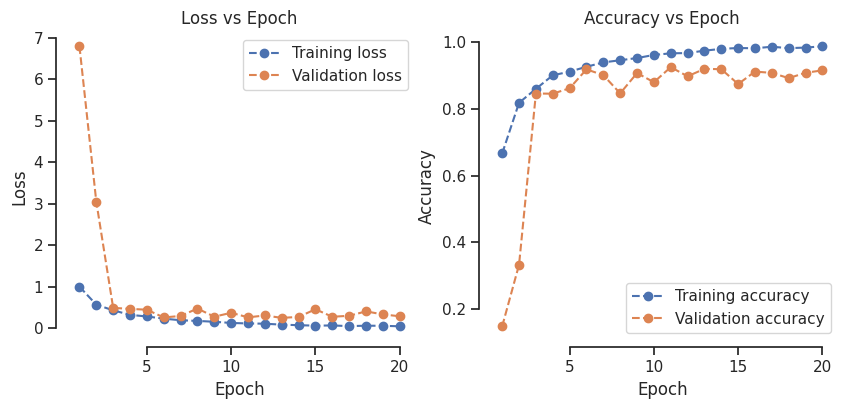

In [ ]:
# TODO plot learning curves

def plot_learning_curves(hist):
    epochs = np.arange(1, len(hist.history['loss']) + 1)
    sns.set(style='ticks')
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    ax[0].plot(epochs, hist.history['loss'], label='Training loss', marker='o', ls='--')
    ax[0].plot(epochs, hist.history['val_loss'], label='Validation loss', marker='o', ls='--')
    ax[0].set_title('Loss vs Epoch')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    ax[1].plot(epochs, hist.history['accuracy'], label='Training accuracy', marker='o', ls='--')
    ax[1].plot(epochs, hist.history['val_accuracy'], label='Validation accuracy', marker='o', ls='--')
    ax[1].set_title('Accuracy vs Epoch')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()

    sns.despine(trim=True, offset=5)
    plt.show()

# Plot curves
plot_learning_curves(history)


# Subtask 2.8
## Transfer learning and fine-tuning

### TensorFlow tutorials
- [Transfer learning and fine-tuning](https://www.tensorflow.org/tutorials/images/transfer_learning)


In this subtask we will learn how to classify images of by using transfer learning from a pre-trained network. A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task. You either use the pre-trained model as is or use transfer learning to customize this model to a given task.

The intuition behind transfer learning for image classification is that if a model is trained on a large and general enough dataset, this model will effectively serve as a generic model of the visual world. You can then take advantage of these learned feature maps without having to start from scratch by training a large model on a large dataset.

Here, we will use `ResNet50`$^1$ pre-trained on `ImageNet` dataset. Let us load the model from `tensorflow.keras.applications`. We remove the fully-connected layers by setting `include_top` as False.

$^1$ [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) (CVPR 2015)

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

Note that we will freeze the parameters of the `ResNet50` by setting `model.trainable = False`.

In [ ]:
input_shape = (img_height, img_width, 3)
input_tensor = preprocess_input(layers.Input(shape=input_shape, name = 'model_inputs'))
resnet50 = ResNet50(weights='imagenet', input_shape=input_shape, input_tensor=input_tensor, include_top=False,)

resnet50.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


We will add new layers on top of the pre-trained `ResNet50` and perform the training process only for the new layers.
#### TODO
- Add a global average pooling and a fully-connected layer on top the `ResNet` model.
- Train the model as before.
- Plot the learning curves.

In [ ]:
# Add custom top layers
x = resnet50.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)  # num_classes = number of your target classes

model_resnet50 = models.Model(inputs=resnet50.input, outputs=outputs)
model_resnet50.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ model_inputs        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ model_inputs[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ model_inputs[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ model_inputs[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ add_4[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# TODO compile and train the model
from tensorflow.keras.callbacks import EarlyStopping

model_resnet50.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',   # use 'sparse_categorical_crossentropy' if labels are integers
    metrics=['accuracy']
)

# Optional: early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_resnet50.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['model_inputs']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


248/248 ━━━━━━━━━━━━━━━━━━━━ 53s 161ms/step - accuracy: 0.6941 - loss: 0.9079 - val_accuracy: 0.9233 - val_loss: 0.2359
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 32s 131ms/step - accuracy: 0.9210 - loss: 0.2429 - val_accuracy: 0.9419 - val_loss: 0.1833
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 36s 110ms/step - accuracy: 0.9397 - loss: 0.1763 - val_accuracy: 0.9475 - val_loss: 0.1578
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.9571 - loss: 0.1273 - val_accuracy: 0.9298 - val_loss: 0.2070
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.9665 - loss: 0.0947 - val_accuracy: 0.9541 - val_loss: 0.1461
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.9706 - loss: 0.0869 - val_accuracy: 0.9571 - val_loss: 0.1412
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.9801 - loss: 0.0642 - val_accuracy: 0.9591 - val_loss: 0.1301
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9814 - loss: 0.0569 - val

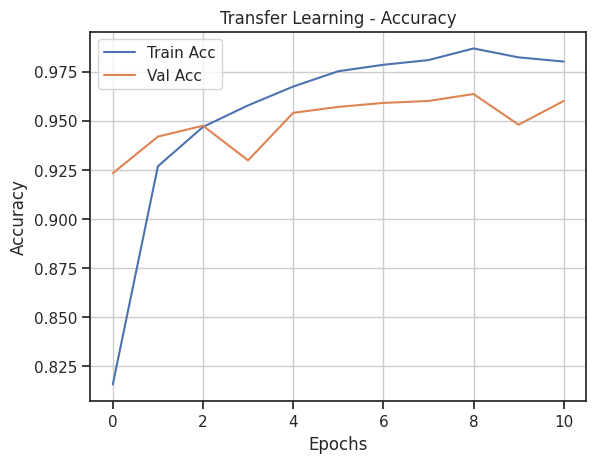

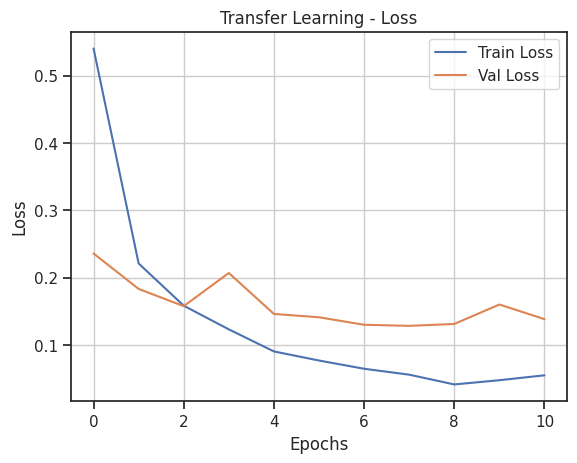

In [ ]:
# TODO plot learning curves

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Transfer Learning - Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Transfer Learning - Loss')
plt.legend()
plt.grid(True)
plt.show()

#### **Questions**
- Does the performance increase compared to the CNNs you trained before? Why/Why not?
- Compare the runtime of your ResNet and ResNet50.

<span style='color:red'>**Your answer:**</span>

1) Yes, the performance typically increases when using ResNet50 with transfer learning, compared to the CNNs you trained from scratch. Here’s why:


*  Pre-trained Knowledge: ResNet50 is pre-trained on ImageNet, a massive dataset with millions of labeled images across thousands of categories. The early layers of this model have already learned general patterns (like edges, shapes, textures) that are useful for a wide range of image classification tasks.

*  Better Feature Extraction: Transfer learning allows your model to use highly optimized and deep feature extractors, which are difficult to learn from scratch, especially when your dataset is relatively small or less diverse.

*  Avoiding Overfitting: Since most weights are frozen (not trained), there are fewer trainable parameters, reducing the risk of overfitting.

2) Comparison

*  The custom ResNet (with four residual blocks) has fewer layers and simpler operations, so each training epoch is generally faster compared to ResNet50.

*  ResNet50, even though its parameters are frozen, contains a much deeper architecture with many convolutional layers, which makes the forward pass computationally more expensive.

*  ResNet50 takes longer per batch or epoch due to its complexity and higher number of operations, even when trained only on the top layers.

*  However, because ResNet50 is already pre-trained on ImageNet, it usually converges faster in terms of validation accuracy and may require fewer epochs to achieve better results.

*  Overall, ResNet50 has a longer per-epoch runtime but can save time across the full training process due to faster convergence.



# Subtask 2.9

## Model performance

#### TODO
- Use the best model you have trained and for the validation dataset report:
    - accuracy
    - precision
    - recall
- Plot the confusion matrix.
    
    


62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step
Accuracy: 0.1565
Precision: 0.1560
Recall: 0.1565


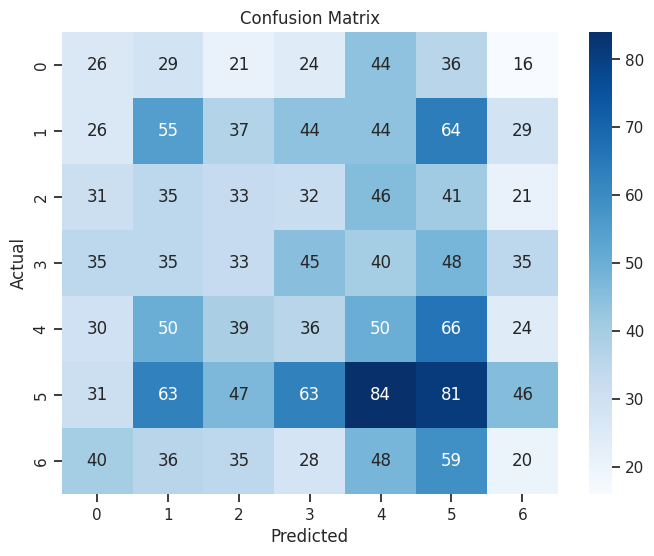

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

val_preds_prob = model.predict(val_ds)
val_preds = np.argmax(val_preds_prob, axis=1)

# real labels
val_labels = []
for _, label in val_ds:
    val_labels.extend(label.numpy())
val_labels = np.array(val_labels)

val_labels = np.array(val_labels)
if val_labels.ndim > 1 and val_labels.shape[1] > 1:
    val_labels = np.argmax(val_labels, axis=1)

#metrics
accuracy = accuracy_score(val_labels, val_preds)
precision = precision_score(val_labels, val_preds, average='weighted')
recall = recall_score(val_labels, val_preds, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

# show the Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


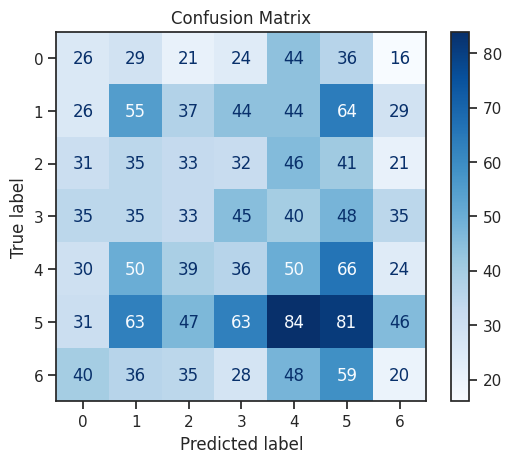

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(val_labels, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Subtask 2.10
## Grad-CAM class activation visualization

Class Activation Maps (CAMs) are visualization methods used for explaining deep learning models. The Grad-CAM technique utilizes the gradients of the classification score with respect to the final convolutional feature map, to identify the parts of an input image that most impact the classification score. The places where this gradient is large are exactly the places where the final score depends most on the data.

Here, we will use the Grad-Cam algorithm to explain why the model is classified an input sample to a certain class.

### TensorFlow Tutorials:
- [Grad-CAM class activation visualization](https://keras.io/examples/vision/grad_cam/#the-gradcam-algorithm)

#### TODO

Employ the model you trained based on the `ResNet50` model. The Grad-CAM algorithm is provided below.

- Use the function and compute the heatmap for an input sample from the validation dataset.
- You should compute the heatmap with respect to the final convolutional feature map: `last_conv_layer_name = conv5_block3_out`. To get the values for `last_conv_layer_name` use `model.summary()` to see the names of all layers in the model.
- Plot the heatmap.


### The Grad-CAM algorithm

In [23]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


#### TODO
 - Visualize one of the samples in the validation dataset.
 - Put the label as the title of the image.

In [24]:
from tensorflow.keras.models import load_model

model_resnet50 = load_model('best_resnet_model.h5')

In [25]:
model_resnet50.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 112, 112,  │        224 │ rescaling_5[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ conv2d_16[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         32 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 112, 112,  │        584 │ batch_normalizat… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ conv2d_17[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 112, 112,  │         32 │ rescaling_5[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         32 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ conv2d_18[0][0],  │
│                     │ 8)                │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ add[0][0]         │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         32 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 56, 56,    │      1,168 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │         64 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 56, 56,    │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 56, 56,    │          0 │ conv2d_20[0][0] 

 Total params: 78,337 (306.01 KB)

 Trainable params: 77,615 (303.18 KB)

 Non-trainable params: 720 (2.81 KB)

 Optimizer params: 2 (12.00 B)

In [28]:
for i, layer in enumerate(model_resnet50.layers):
    print(i, layer.name)

0 input_layer_5
1 rescaling_5
2 conv2d_16
3 re_lu
4 batch_normalization_4
5 conv2d_17
6 re_lu_1
7 conv2d_18
8 batch_normalization_5
9 add
10 re_lu_2
11 batch_normalization_6
12 conv2d_19
13 re_lu_3
14 batch_normalization_7
15 conv2d_20
16 re_lu_4
17 conv2d_21
18 batch_normalization_8
19 add_1
20 re_lu_5
21 batch_normalization_9
22 conv2d_22
23 re_lu_6
24 batch_normalization_10
25 conv2d_23
26 re_lu_7
27 conv2d_24
28 batch_normalization_11
29 add_2
30 re_lu_8
31 batch_normalization_12
32 conv2d_25
33 re_lu_9
34 batch_normalization_13
35 conv2d_26
36 re_lu_10
37 conv2d_27
38 batch_normalization_14
39 add_3
40 re_lu_11
41 batch_normalization_15
42 global_average_pooling2d_3
43 dense_7


In [30]:
# TODO visualize one image sample
image_batch, label_batch = next(iter(val_ds))
img = image_batch[0]
label = label_batch[0].numpy()

img_array = tf.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(img_array, model_resnet50, last_conv_layer_name='conv2d_27')

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_5']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


You can use the following function to create and display a superimposed visualization:

<ipython-input-34-1669200730>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


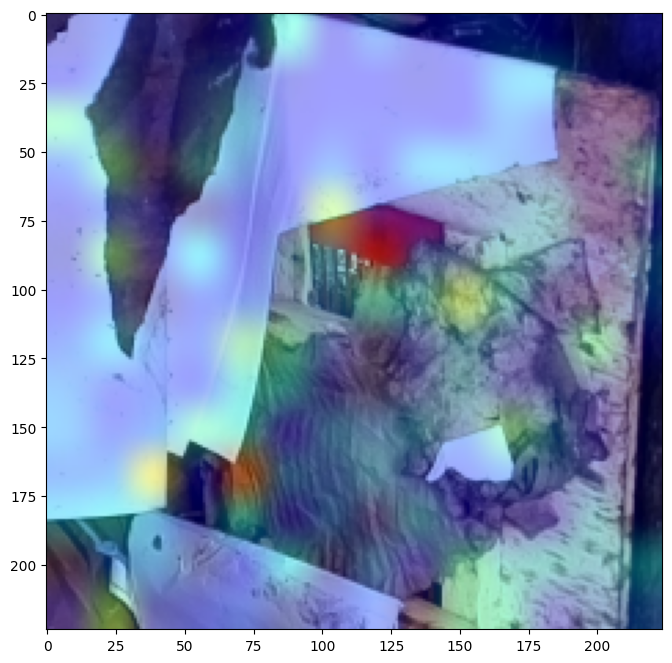

In [34]:
def save_and_display_gradcam(img, heatmap, alpha=0.6):

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)



# TODO plot the superimposed image
save_and_display_gradcam(img, heatmap)


#### **Questions**
- Explain the model performance based on the obtained results from Grad-CAM.
- Does the model perform properly? Why/why not?
- How we can improve the model performance?

<span style='color:red'>**Your answer:**</span>

1)
 No, the model doesn't perform properly.
*  Based on the Grad-CAM heatmap, the model's attention is scattered across the image. It doesn't focus clearly on a specific object. This suggests that the model might be confused and is unsure about which parts of the image are important for its decision.

2)
*  Low-quality or noisy data. Images may be blurry or have incorrect labels.

*  Incomplete training. The model may be underfitted or overfitted.

*  Wrong Grad-CAM layer used. The selected layer might not provide meaningful feature maps.

*  Complex image content. The model might struggle to identify key features in cluttered scenes.

3)
*  Use cleaner and more diverse data. Make sure images are sharp and well-labeled.

*  Try a different layer for Grad-CAM. An earlier layer might show better-focused heatmaps.

*  Apply data augmentation. It helps the model generalize better.

*  Fine-tune the pretrained model. Unfreeze and retrain some of the top layers.

*  Check the model's confidence scores. If the predictions have low confidence, the model might be uncertain.
